In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv("Amazon_Sale_Report_Cleaned.csv")
print("Shape:", df.shape)
print(df.head())

Shape: (121149, 23)
   index             Order ID        Date                        Status  \
0      0  405-8078784-5731545  2022-04-30                     Cancelled   
1      1  171-9198151-1101146  2022-04-30  Shipped - Delivered to Buyer   
2      2  404-0687676-7273146  2022-04-30                       Shipped   
3      3  403-9615377-8133951  2022-04-30                     Cancelled   
4      4  407-1069790-7240320  2022-04-30                       Shipped   

  Fulfilment Sales Channel  ship-service-level    Style              SKU  \
0   Merchant      Amazon.in           Standard   SET389   SET389-KR-NP-S   
1   Merchant      Amazon.in           Standard  JNE3781  JNE3781-KR-XXXL   
2     Amazon      Amazon.in          Expedited  JNE3371    JNE3371-KR-XL   
3   Merchant      Amazon.in           Standard    J0341       J0341-DR-L   
4     Amazon      Amazon.in          Expedited  JNE3671  JNE3671-TU-XXXL   

        Category Size        ASIN Courier Status  Qty currency  Amount  

In [4]:
print(df.info())
print(df.describe(include='all').T)


<class 'pandas.DataFrame'>
RangeIndex: 121149 entries, 0 to 121148
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               121149 non-null  int64  
 1   Order ID            121149 non-null  str    
 2   Date                121149 non-null  str    
 3   Status              121149 non-null  str    
 4   Fulfilment          121149 non-null  str    
 5   Sales Channel       121149 non-null  str    
 6   ship-service-level  121149 non-null  str    
 7   Style               121149 non-null  str    
 8   SKU                 121149 non-null  str    
 9   Category            121149 non-null  str    
 10  Size                121149 non-null  str    
 11  ASIN                121149 non-null  str    
 12  Courier Status      121149 non-null  str    
 13  Qty                 121149 non-null  int64  
 14  currency            121149 non-null  str    
 15  Amount              121149 non-null  float64


In [6]:
print("Missing values:\n", df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Month'] = df['Date'].dt.month_name()
df['Weekday'] = df['Date'].dt.day_name()
df['MonthPeriod'] = df['Date'].dt.to_period('M').astype(str)


Missing values:
 index                 0
Order ID              0
Date                  0
Status                0
Fulfilment            0
Sales Channel         0
ship-service-level    0
Style                 0
SKU                   0
Category              0
Size                  0
ASIN                  0
Courier Status        0
Qty                   0
currency              0
Amount                0
ship-city             0
ship-state            0
ship-postal-code      0
ship-country          0
promotion-ids         0
B2B                   0
fulfilled-by          0
dtype: int64
Duplicate rows: 0


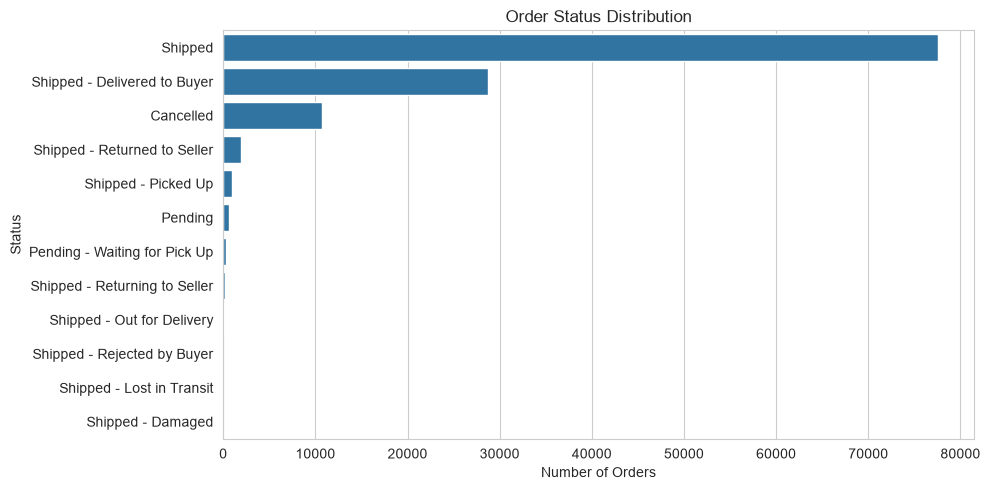

In [7]:
plt.figure(figsize=(10, 5))
order = df['Status'].value_counts().index
sns.countplot(data=df, y='Status', order=order)
plt.title('Order Status Distribution')
plt.xlabel('Number of Orders')
plt.tight_layout()
plt.show()

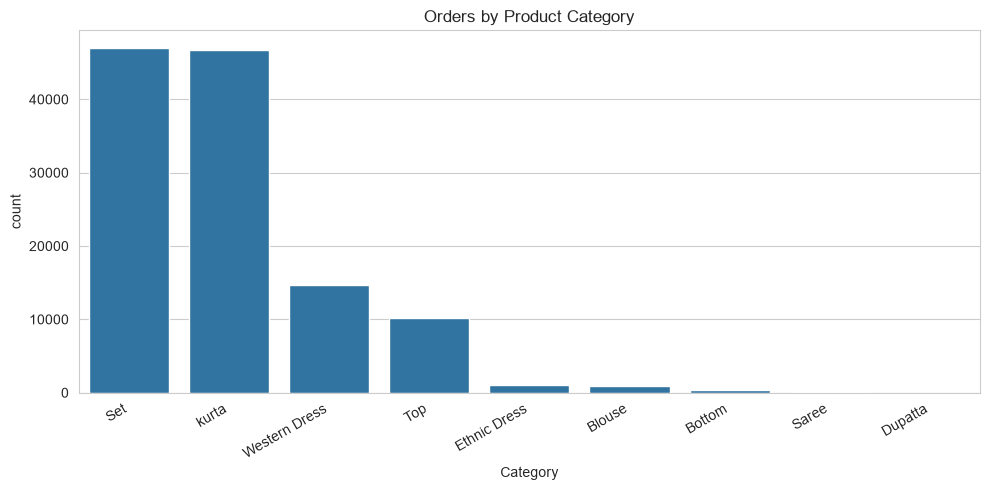

In [8]:
plt.figure(figsize=(10, 5))
order = df['Category'].value_counts().index
sns.countplot(data=df, x='Category', order=order)
plt.title('Orders by Product Category')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


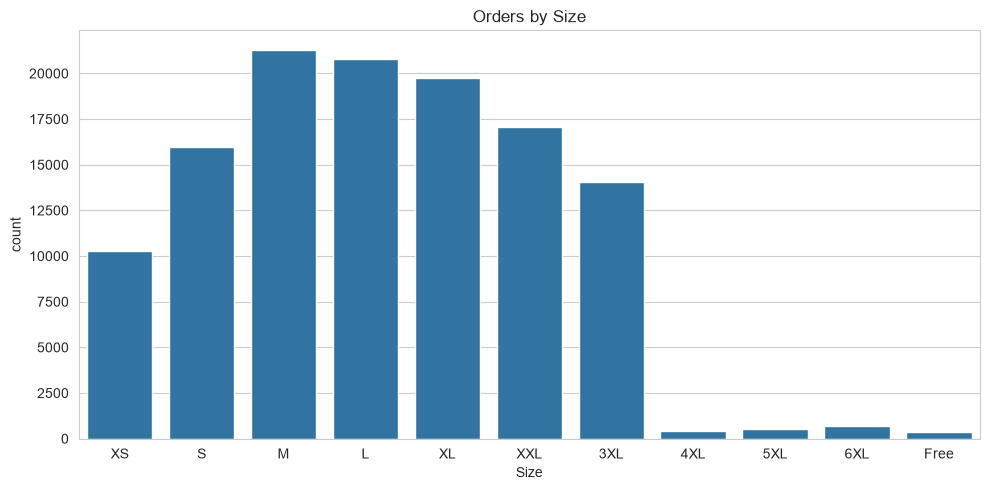

In [9]:
plt.figure(figsize=(10, 5))
size_order = ['XS', 'S', 'M', 'L', 'XL', 'XXL', '3XL', '4XL', '5XL', '6XL', 'Free']
present = [s for s in size_order if s in df['Size'].unique()]
sns.countplot(data=df, x='Size', order=present)
plt.title('Orders by Size')
plt.tight_layout()
plt.show()


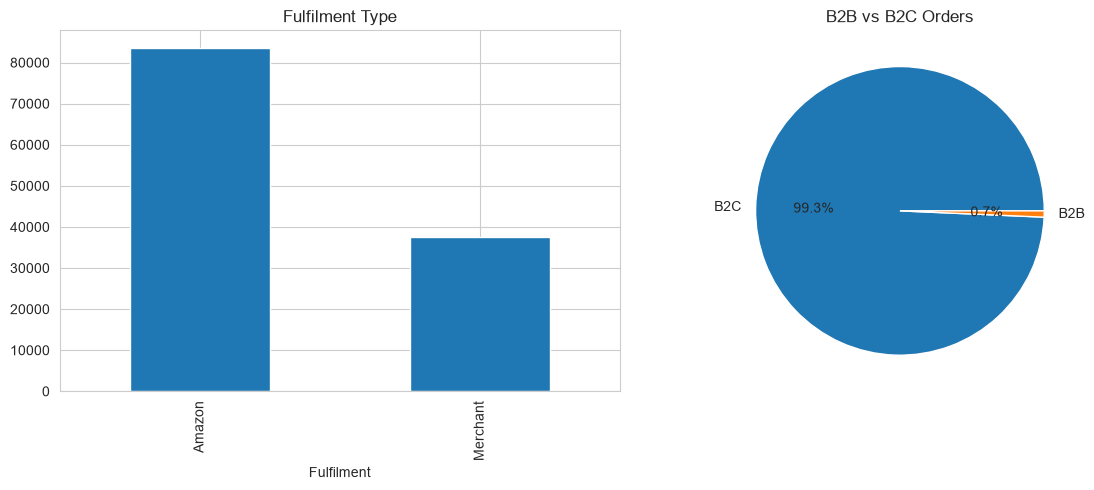

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
df['Fulfilment'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Fulfilment Type')

df['B2B'].value_counts().rename({True: 'B2B', False: 'B2C'}).plot(
    kind='pie', ax=axes[1], autopct='%1.1f%%')
axes[1].set_title('B2B vs B2C Orders')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

In [12]:
total_orders = len(df)
total_revenue = df['Amount'].sum()
total_qty = df['Qty'].sum()
avg_order_value = df['Amount'].mean()
cancelled_pct = (df['Status'] == 'Cancelled').mean() * 100

print(f"Total Orders        : {total_orders:,}")
print(f"Total Revenue (INR) : {total_revenue:,.2f}")
print(f"Total Quantity Sold : {total_qty:,}")
print(f"Average Order Value : {avg_order_value:,.2f} INR")
print(f"Cancellation Rate   : {cancelled_pct:.2f}%")


Total Orders        : 121,149
Total Revenue (INR) : 78,574,007.30
Total Quantity Sold : 116,454
Average Order Value : 648.57 INR
Cancellation Rate   : 8.88%


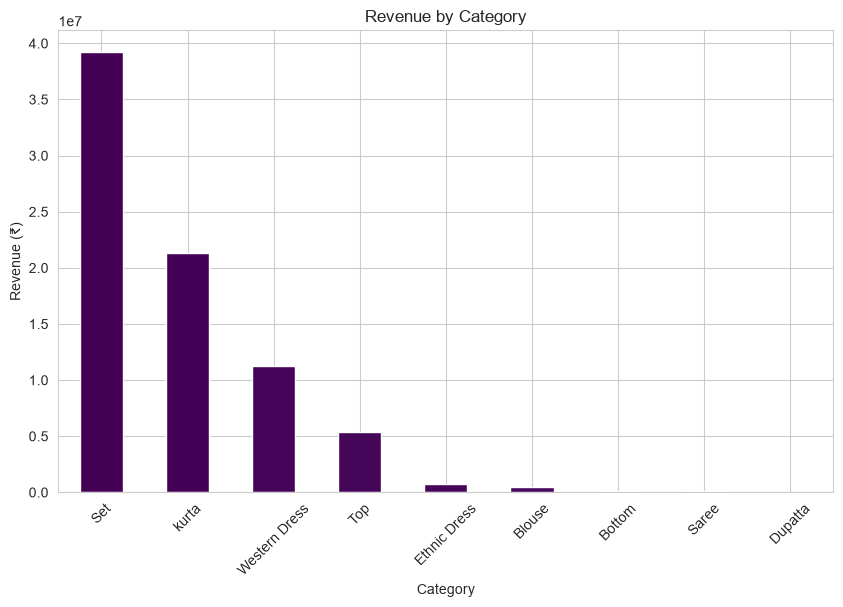

In [14]:
plt.figure(figsize=(10,6))

revenue_category = df.groupby('Category')['Amount'].sum().sort_values(ascending=False)

revenue_category.plot(
    kind='bar',
    color=plt.cm.viridis(range(len(revenue_category)))
)

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=45)

plt.show()

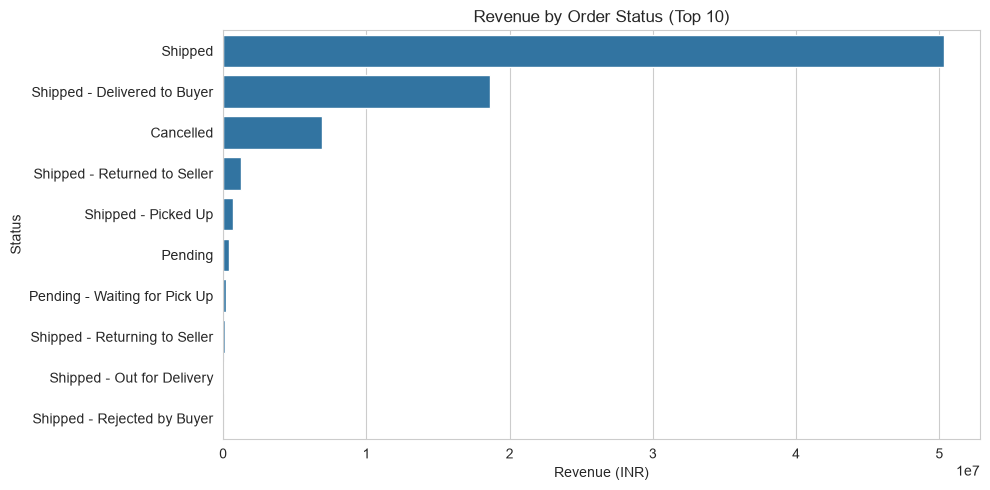

In [15]:
rev_by_status = df.groupby('Status')['Amount'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=rev_by_status.values, y=rev_by_status.index)
plt.title('Revenue by Order Status (Top 10)')
plt.xlabel('Revenue (INR)')
plt.tight_layout()
plt.show()


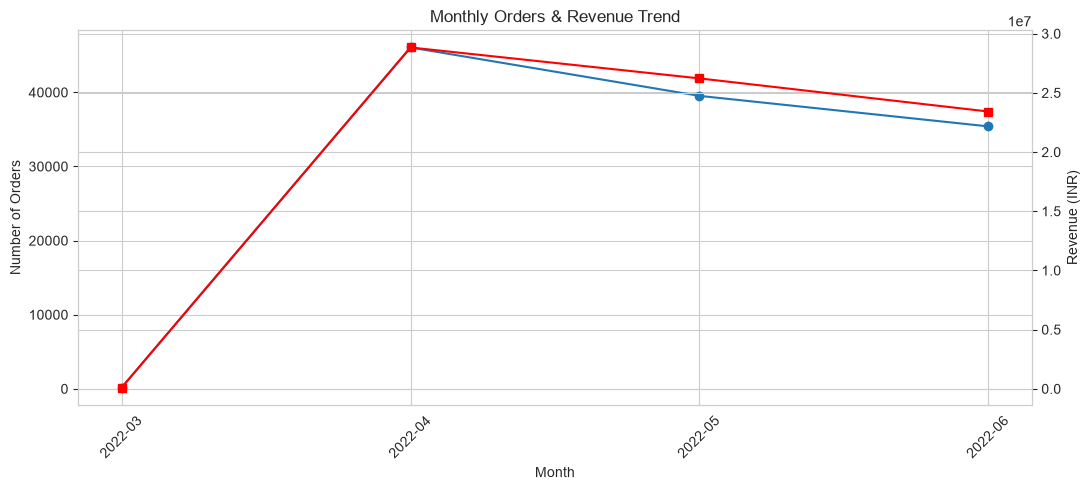

In [16]:
monthly = df.groupby('MonthPeriod').agg(Orders=('Order ID', 'count'),
                                         Revenue=('Amount', 'sum')).reset_index()

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()
ax1.plot(monthly['MonthPeriod'], monthly['Orders'], marker='o', label='Orders')
ax2.plot(monthly['MonthPeriod'], monthly['Revenue'], marker='s', color='red', label='Revenue')
ax1.set_xlabel('Month')
ax1.set_ylabel('Number of Orders')
ax2.set_ylabel('Revenue (INR)')
plt.title('Monthly Orders & Revenue Trend')
ax1.tick_params(axis='x', rotation=45)
fig.tight_layout()
plt.show()

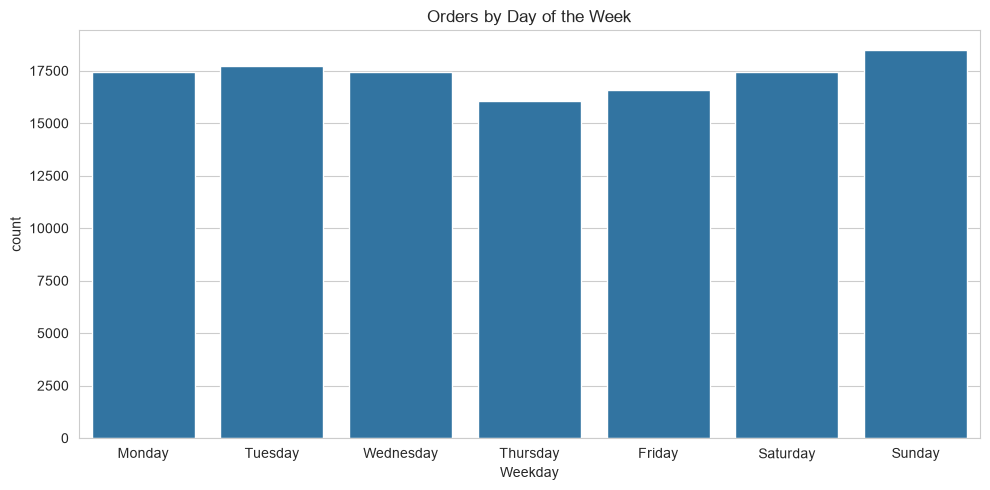

In [17]:
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Weekday', order=weekday_order)
plt.title('Orders by Day of the Week')
plt.tight_layout()
plt.show()

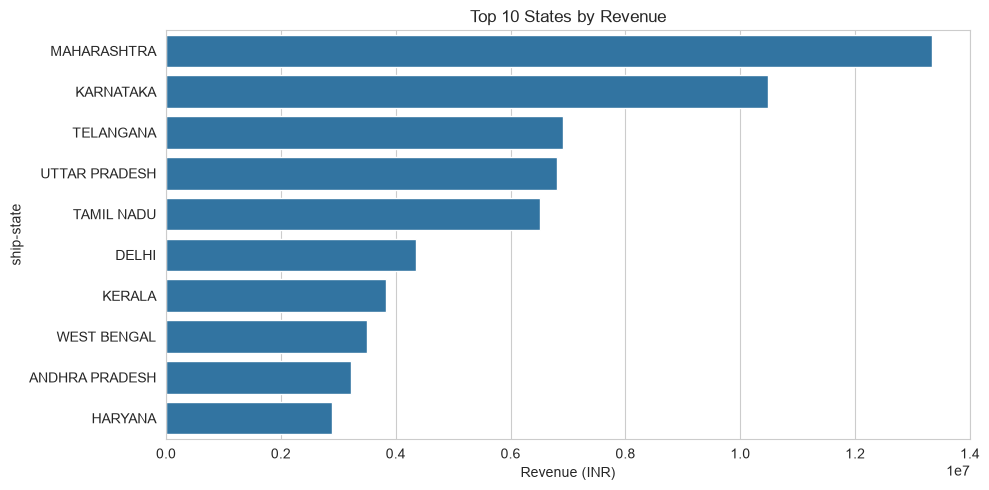

In [18]:
top_states = df.groupby('ship-state')['Amount'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_states.values, y=top_states.index)
plt.title('Top 10 States by Revenue')
plt.xlabel('Revenue (INR)')
plt.tight_layout()
plt.show()

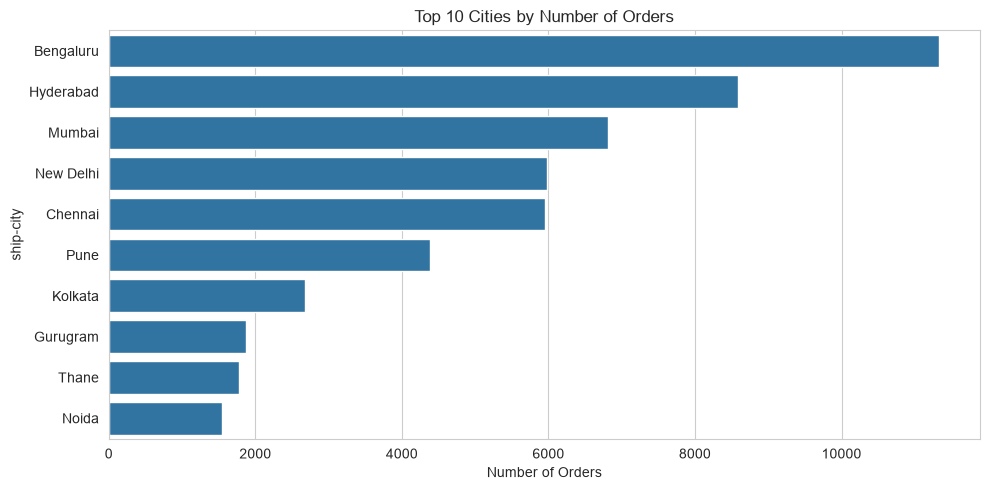

In [19]:
top_cities = df['ship-city'].value_counts().head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_cities.values, y=top_cities.index)
plt.title('Top 10 Cities by Number of Orders')
plt.xlabel('Number of Orders')
plt.tight_layout()
plt.show()

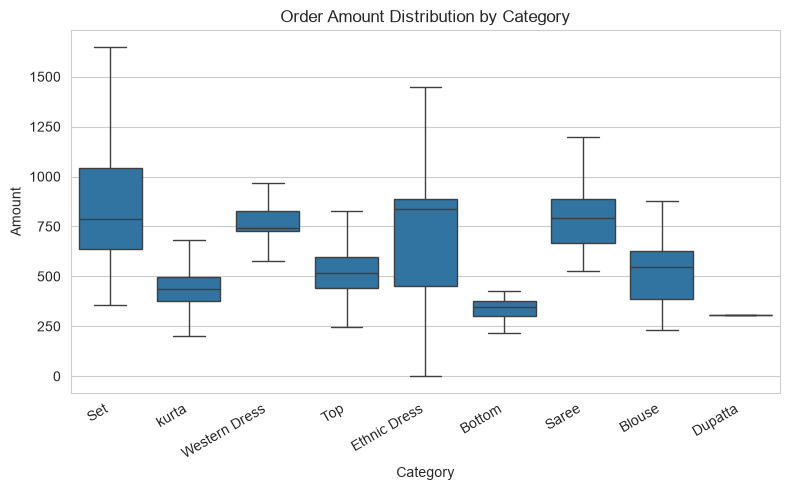

In [20]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Category', y='Amount', showfliers=False)
plt.title('Order Amount Distribution by Category')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

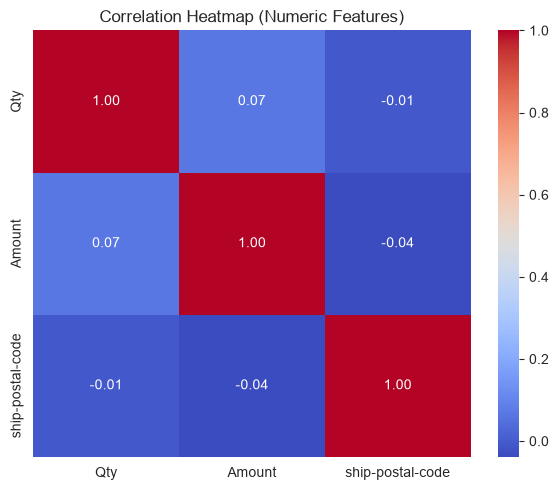

In [21]:
numeric_df = df[['Qty', 'Amount', 'ship-postal-code']]
corr = numeric_df.corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Numeric Features)')
plt.tight_layout()
plt.show()

In [22]:
top_category = df['Category'].value_counts().idxmax()
top_state = df.groupby('ship-state')['Amount'].sum().idxmax()
top_month = monthly.loc[monthly['Revenue'].idxmax(), 'MonthPeriod']
b2b_pct = (df['B2B'] == True).mean() * 100

print("KEY INSIGHTS")
print(f"1. Most ordered category      : {top_category}")
print(f"2. Highest revenue state      : {top_state}")
print(f"3. Best performing month      : {top_month}")
print(f"4. B2B share of total orders  : {b2b_pct:.2f}%")
print(f"5. Overall cancellation rate  : {cancelled_pct:.2f}%")
print(f"6. Average order value        : {avg_order_value:,.2f} INR")


KEY INSIGHTS
1. Most ordered category      : Set
2. Highest revenue state      : MAHARASHTRA
3. Best performing month      : 2022-04
4. B2B share of total orders  : 0.70%
5. Overall cancellation rate  : 8.88%
6. Average order value        : 648.57 INR
